In [1]:
import numpy as np
import matplotlib.pyplot as plt
from CIDER import response_from_all_injections_and_CO2,AOD_from_injection, pattern_from_all_injections_and_CO2
from Toolbox import global_mean, lat_band_mean, stack_and_zoh_injections
import CIDER

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import os

import xesmf as xe
import pandas as pd

plt.rcParams.update({'font.size': 13})

## important - define CIDER version first (UKESM / CESM) 

we need to use both versions, so run emulation for one, and then return here, 
change the model as described below and run code for the other.
Nothing else in this notebook needs to be changed between the two versions.

go to CIDER's 'load_all_other_variables.py' and change the following line:

mat = scipy.io.loadmat(f'parameters/UKESM_params.mat')

to the following:

#model = 'CESM' <br>
model = 'UKESM' <br>
mat = scipy.io.loadmat(f'parameters/{model}_params.mat') 

to be able to swap between models. comment out whichever is not in use.




In [11]:
run load_all_other_variables.py

In [12]:
print(model) # to check which version is activated

CESM


# Definining our scenarios

In [13]:
end_yr = 2100
start_yr = 2035
yrs_per_cycle = 1

# set number of years

total_years = end_yr - start_yr
years_represented_by_array_element = yrs_per_cycle # 1/ ArrayLength 
n_yrs = end_yr - start_yr
if n_yrs % yrs_per_cycle != 0:
    raise ValueError(f"Number of years ({n_yrs}) is not a whole number of cycles ({yrs_per_cycle}-year).")

n_cycles = n_yrs / yrs_per_cycle

# these are for Arc High 
rampup_max = 10  # max inj in Tg / yr
rampup_period = 20 # in yrs 

rampup_cycles = rampup_period / yrs_per_cycle
rampup_step = rampup_max / rampup_cycles

inj_rampup = np.arange(0,rampup_max, rampup_step)
inj_constant = np.full(int(n_cycles - len(inj_rampup))+1, rampup_max)

inj = np.concat([inj_rampup[1:], inj_constant])

inj_zeros = np.zeros(int(n_yrs/yrs_per_cycle))

#these are Tg/yr, each number in array corresponding to number of years defined above

In [14]:
# no injection scenarios

no_injection = np.zeros((total_years*12, 7))
no_injection_and_CO2 = np.concatenate((no_injection,CO2_forcing_SSP245_month[0:total_years*12].reshape(total_years*12, 1)),axis=1)

SSP245_T_response = response_from_all_injections_and_CO2(no_injection_and_CO2, param_AOD_all, param_T_all)
SSP245_T_pattern = pattern_from_all_injections_and_CO2(no_injection_and_CO2, param_AOD_all, param_T_all, all_T_patterns_scaled)

s245_name = 'SSP245'

In [15]:
# 1 - ARCTIC HIGH

scen1_name = 'Arctic High'

i_60N = np.array(inj)
i_60N_a1 = i_60N

i_30N, i_15N, i_0NS, i_15S, i_30S, i_60S = inj_zeros,inj_zeros,inj_zeros,inj_zeros,inj_zeros,inj_zeros 


i_scen1 = stack_and_zoh_injections((i_60N, i_30N, i_15N, i_0NS, i_15S, i_30S, i_60S),years_represented_by_array_element*12)
all_injection_and_CO2_scen1 = np.concatenate((i_scen1,CO2_forcing_SSP245_month[0:total_years*12].reshape(total_years*12, 1)),axis=1)

# 2 - ARCTIC LOW

scen2_name = 'Arctic Low'

# i_60N = np.array([2,4,5,6,7,8,9,10,10,11,11,12,12])/2 #original 
i_60N = np.array(inj)/2 
i_60N_a2 = i_60N

i_30N, i_15N, i_0NS, i_15S, i_30S, i_60S = inj_zeros,inj_zeros,inj_zeros,inj_zeros,inj_zeros,inj_zeros 

i_scen2 = stack_and_zoh_injections((i_60N, i_30N, i_15N, i_0NS, i_15S, i_30S, i_60S),years_represented_by_array_element*12)
all_injection_and_CO2_scen2 = np.concatenate((i_scen2,CO2_forcing_SSP245_month[0:total_years*12].reshape(total_years*12, 1)),axis=1)

# 3 - GLOBAL

scen3_name = 'Global'

i_60N = np.array(inj)/7
i_30N = np.array(inj)/7
i_15N = np.array(inj)/7
i_0NS = np.array(inj)/7
i_15S = np.array(inj)/7
i_30S = np.array(inj)/7
i_60S = np.array(inj)/7

i_scen3 = stack_and_zoh_injections((i_60N, i_30N, i_15N, i_0NS, i_15S, i_30S, i_60S),years_represented_by_array_element*12)
all_injection_and_CO2_scen3 = np.concatenate((i_scen3,CO2_forcing_SSP245_month[0:total_years*12].reshape(total_years*12, 1)),axis=1)

# 4 - ANTARCTIC

scen4_name = 'Antarctic'

i_60N, i_30N, i_15N, i_0NS, i_15S, i_30S = inj_zeros,inj_zeros,inj_zeros,inj_zeros,inj_zeros,inj_zeros 

i_60S = np.array(inj)

i_scen4 = stack_and_zoh_injections((i_60N, i_30N, i_15N, i_0NS, i_15S, i_30S, i_60S),years_represented_by_array_element*12)
all_injection_and_CO2_scen4 = np.concatenate((i_scen4,CO2_forcing_SSP245_month[0:total_years*12].reshape(total_years*12, 1)),axis=1)

In [16]:
# getting patterns and responses for each scenario

scen1_pattern = pattern_from_all_injections_and_CO2(all_injection_and_CO2_scen1, param_AOD_all, param_T_all, all_T_patterns_scaled)
scen2_pattern = pattern_from_all_injections_and_CO2(all_injection_and_CO2_scen2, param_AOD_all, param_T_all, all_T_patterns_scaled)
scen3_pattern = pattern_from_all_injections_and_CO2(all_injection_and_CO2_scen3, param_AOD_all, param_T_all, all_T_patterns_scaled)
scen4_pattern = pattern_from_all_injections_and_CO2(all_injection_and_CO2_scen4, param_AOD_all, param_T_all, all_T_patterns_scaled)
scen_patterns = [SSP245_T_pattern, scen1_pattern, scen2_pattern, scen3_pattern, scen4_pattern]

scen1_response = response_from_all_injections_and_CO2(all_injection_and_CO2_scen1, param_AOD_all, param_T_all)
scen2_response = response_from_all_injections_and_CO2(all_injection_and_CO2_scen2, param_AOD_all, param_T_all)
scen3_response = response_from_all_injections_and_CO2(all_injection_and_CO2_scen3, param_AOD_all, param_T_all)
scen4_response = response_from_all_injections_and_CO2(all_injection_and_CO2_scen4, param_AOD_all, param_T_all)
scen_responses = [SSP245_T_response, scen1_response, scen2_response, scen3_response, scen4_response]


In [17]:
'''
# response months into years
scen_resp_list = []

for i in scen_responses:
    response_reshaped = i.reshape(65,12)
    rr_mean = response_reshaped.mean(axis = -1)
    scen_resp_list.append(rr_mean)
'''
# creating coordinates 

lon = np.linspace(0, 360, 288, endpoint=False)
lat = np.linspace(-90, 90, 192)
years_2035_2100 = np.arange(2035,2100,1)
years_1855_2095 = np.arange(1855,2096,1)
years_2035_2095 = np.arange(2035,2096,1)

lat2d, lon2d = np.meshgrid(lat, lon)

lat2d_NH = lat2d[:, 96:] 
lon2d_NH = lon2d[:, 96:] 

lat2d_SH = lat2d[:, :96] 
lon2d_SH = lon2d[:, :96] 

weights = np.cos(np.deg2rad(lat))
weights_NH = weights[96:] 
weights_SH = weights[:96] 

In [18]:
# creating NH, SH, IHTD 

scens_IHTD = []
scens_NHs = []
scens_SHs = []
scens_pats = []
scen_names = [s245_name, scen1_name, scen2_name, scen3_name, scen4_name]

for i in range(len(scen_patterns)):
    SAI_pattern_reshaped = scen_patterns[i].reshape(288, 192, total_years, 12) # split inot years and months
    SAI_pat = SAI_pattern_reshaped.mean(axis=-1)   # avg over years
    scens_pats.append(SAI_pat)
    
    SAI_NH_pat = SAI_pat[:, 96: , :]  # isolate NH   # cause lats are from -90 to 90
    SAI_SH_pat = SAI_pat[:, :96 , :]  # isolate SH
    
    SAI_NH_avglat = np.average(SAI_NH_pat, weights = weights_NH, axis = 1)
    SAI_NH = np.average(SAI_NH_avglat, axis = 0)
    scens_NHs.append(SAI_NH)
    
    SAI_SH_avglat = np.average(SAI_SH_pat, weights = weights_SH, axis = 1)
    SAI_SH = np.average(SAI_SH_avglat, axis = 0)
    scens_SHs.append(SAI_SH)
    
    SAI_ITD = SAI_NH - SAI_SH
    scens_IHTD.append(SAI_ITD)


In [19]:
if model == 'UKESM':
    scens_IHTD_UKESM, scens_NHs_UKESM, scens_SHs_UKESM, scens_pats_UKESM, scen_names_UKESM = scens_IHTD, scens_NHs, scens_SHs, scens_pats,  scen_names
elif model == 'CESM':
    scens_IHTD_CESM, scens_NHs_CESM, scens_SHs_CESM, scens_pats_CESM, scen_names_CESM = scens_IHTD, scens_NHs, scens_SHs, scens_pats, scen_names


# !!!  Stop here and change model !!!

## rerun from beginning to get both UKESM and CESM data defined. 
## after running from beginning for each model, continue down

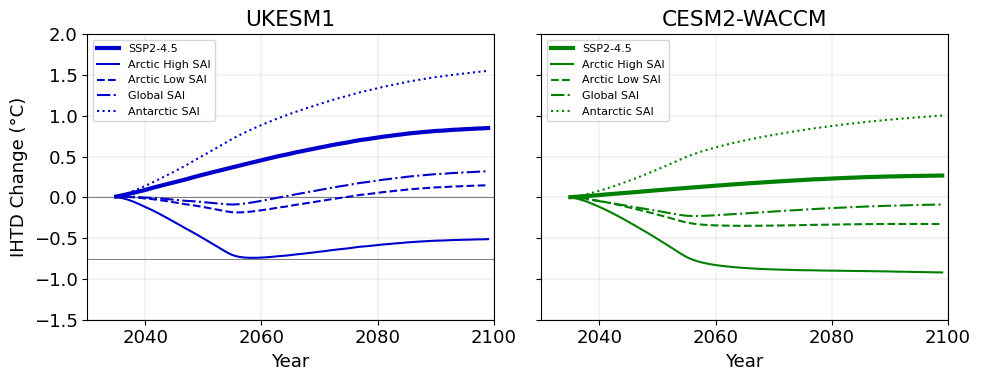

In [20]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)

lss = ['-', '--', '-.', ':']

# UKESM
ax = axs[0]

ax.plot([2030, 2100], [-0.75, -0.75], c='grey', lw=0.75)
ax.plot([2030, 2100], [0, 0], c='grey', lw=0.75)

ax.plot(years_2035_2100, scens_IHTD_UKESM[0], color='mediumblue', linestyle='-', lw=3, label='SSP2-4.5')
for i in range(len(scens_IHTD) - 1):
    ax.plot(years_2035_2100, scens_IHTD_UKESM[i + 1],
            color='mediumblue', linestyle=lss[i], label=f'{scen_names[i + 1]} SAI')
ax.legend(fontsize=8)

ax.set_xlabel('Year')
ax.set_ylabel('IHTD Change (°C)')
ax.set_ylim(-1.5, 2)
ax.set_xlim(2030, 2100)
ax.set_xticks(range(2040, 2101, 20))  
ax.set_title('UKESM1')
ax.grid(lw=0.07, c='black')

# CESM
ax = axs[1]
ax.plot(years_2035_2100, scens_IHTD_CESM[0], color='green', linestyle='-', lw=3, label='SSP2-4.5')
for i in range(len(scens_IHTD) - 1):
    ax.plot(years_2035_2100, scens_IHTD_CESM[i + 1],
            color='green', linestyle=lss[i], label=f'{scen_names[i + 1]} SAI')
ax.legend(fontsize=8)

ax.set_xlabel('Year')
ax.set_ylim(-1.5, 2)
ax.set_xlim(2030, 2100)
ax.set_xticks(range(2040, 2101, 20))  
ax.set_title('CESM2-WACCM')
ax.grid(lw=0.07, c='black')

plt.tight_layout()
plt.savefig('PD_figures/Fig_S4.jpg', dpi=350)
plt.show()


# Joining CIDER and model

In [21]:
UKESM_ens = pd.read_pickle('PD_extra2plot/UKESM_ens_pickle')
CESM_ens = pd.read_pickle('PD_extra2plot/CESM_ens_pickle')

present_era5 = 1.9663

diff_UKESM = UKESM_ens.ihtd[166] - present_era5   # cause 0 = 1855 
diff_CESM = CESM_ens.ihtd[166] - present_era5   # cause 0 = 1855 

UKESM_ens_e5 = UKESM_ens.ihtd - diff_UKESM
CESM_ens_e5 = CESM_ens.ihtd - diff_CESM

# def function

def itd_change_for_scen_UKESM(SAI_ITD, s245_ITD):
    SAI_ITD_short = SAI_ITD[:61]
    s245_ITD_short = s245_ITD[:61]
    SAI_change = s245_ITD_short - SAI_ITD_short
    SAI_changed = df.itd_anom[16][-61:] - SAI_change
    return SAI_change, SAI_changed

def itd_change_for_scen_CESM(SAI_ITD, s245_ITD):
    SAI_ITD_short = SAI_ITD[:61]
    s245_ITD_short = s245_ITD[:61]
    SAI_change = s245_ITD_short - SAI_ITD_short
    SAI_changed = df.itd_anom[17][-61:] - SAI_change
    return SAI_change, SAI_changed

def itd_change_for_scen_UKESM_ens(SAI_ITD, s245_ITD):
    SAI_ITD_short = SAI_ITD[:61]
    s245_ITD_short = s245_ITD[:61]
    SAI_change = s245_ITD_short - SAI_ITD_short
    SAI_changed = UKESM_ens_e5[-61:] - SAI_change
    return SAI_change, SAI_changed

def itd_change_for_scen_CESM_ens(SAI_ITD, s245_ITD):
    SAI_ITD_short = SAI_ITD[:61]
    s245_ITD_short = s245_ITD[:61]
    SAI_change = s245_ITD_short - SAI_ITD_short
    SAI_changed = CESM_ens_e5[-61:] - SAI_change
    return SAI_change, SAI_changed

In [22]:
# run separately 

UKESM_SAI_change = []
UKESM_SAI_changed = []
for i in range(len(scens_IHTD)):
    scen_UKESM_change, scen_UKESM_changed = itd_change_for_scen_UKESM_ens(scens_IHTD_UKESM[i], scens_IHTD_UKESM[0])
    UKESM_SAI_change.append(scen_UKESM_change)
    UKESM_SAI_changed.append(scen_UKESM_changed)

CESM_SAI_change = []
CESM_SAI_changed = []
for i in range(len(scens_IHTD)):
    scen_CESM_change, scen_CESM_changed = itd_change_for_scen_CESM_ens(scens_IHTD_CESM[i], scens_IHTD_CESM[0])
    CESM_SAI_change.append(scen_CESM_change)
    CESM_SAI_changed.append(scen_CESM_changed)   

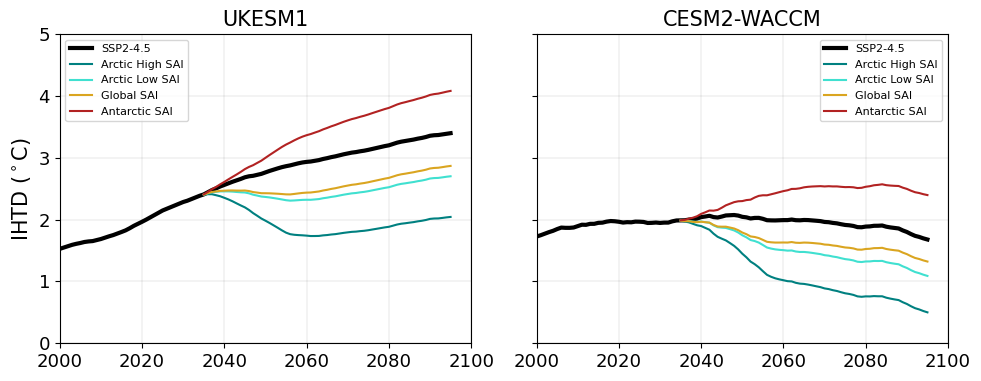

In [23]:
# all scenarios

fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize=(10, 4), sharey = True)

ax = axs[0]

ax.plot(years_1855_2095, UKESM_ens_e5[1:], color = 'black', ls = '-', lw = 3, label = 'SSP2-4.5')
ax.plot(years_2035_2095, UKESM_SAI_changed[1], color='teal', linestyle='-', label=f'{scen_names[1]} SAI')
ax.plot(years_2035_2095, UKESM_SAI_changed[2], color='turquoise', label=f'{scen_names[2]} SAI') 
ax.plot(years_2035_2095, UKESM_SAI_changed[3], color='goldenrod', label=f'{scen_names[3]} SAI') 
ax.plot(years_2035_2095, UKESM_SAI_changed[4], color='firebrick', label=f'{scen_names[4]} SAI') 

ax.set_xlim(2000,2100)
#ax.set_ylim(-2, 3)
ax.legend(fontsize = 8)
ax.set_title('UKESM1', fontsize = 15)
ax.set_ylabel('IHTD ($^\circ$C)', fontsize=15)
ax.grid(lw = 0.07, c = 'black')


ax = axs[1]

ax.plot(years_1855_2095, CESM_ens_e5[1:], color = 'black', ls = '-', lw = 3, label = 'SSP2-4.5')
ax.plot(years_2035_2095, CESM_SAI_changed[1], color='teal', linestyle='-', label=f'{scen_names[1]} SAI')
ax.plot(years_2035_2095, CESM_SAI_changed[2], color='turquoise', label=f'{scen_names[2]} SAI') 
ax.plot(years_2035_2095, CESM_SAI_changed[3], color='goldenrod', label=f'{scen_names[3]} SAI') 
ax.plot(years_2035_2095, CESM_SAI_changed[4], color='firebrick', label=f'{scen_names[4]} SAI') 

ax.set_xlim(2000,2100)
ax.set_ylim(0,5)
ax.legend(fontsize = 8)
ax.set_title('CESM2-WACCM', fontsize = 15)
ax.grid(lw = 0.07, c = 'black')

plt.tight_layout()
plt.savefig('PD_figures/Fig2_cider_imposed_ihtd.jpg', dpi = 350)
plt.show()